In [3]:
%pip install -U pip setuptools wheel
%pip install tensorflow-macos tensorflow-metal jupyterlab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 2.4 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.8 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 1.5 MB/s eta 0:00:0000:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 65.5.0
    Uninstalling setuptools-65.5.0:
      Successfully uninstalled setuptools-65.5.0
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1
Note: you may need to restart the kernel to use updated packages.
  Using cached tensorflow_macos-2.16.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (3.3 kB)
  Using cached tensorflow_metal-1.2.0-cp310-cp310-macosx_12_0_arm64.whl.metadata (1.3 kB)
  Using cached tensorflow-2.16.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (4.1 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached fla

In [5]:
%pip install numpy==1.26.4

Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.16.2
Num GPUs Available: 1


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [5]:
df=pd.read_csv("audio_main.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 39 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1440 non-null   int64  
 1   file_path      1440 non-null   object 
 2   modality       1440 non-null   int64  
 3   vocal_channel  1440 non-null   int64  
 4   emotion        1440 non-null   object 
 5   emotion_code   1440 non-null   int64  
 6   intensity      1440 non-null   int64  
 7   statement      1440 non-null   int64  
 8   repetition     1440 non-null   int64  
 9   actor          1440 non-null   int64  
 10  gender         1440 non-null   object 
 11  id             1440 non-null   object 
 12  mfcc_0         1440 non-null   float64
 13  mfcc_1         1440 non-null   float64
 14  mfcc_2         1440 non-null   float64
 15  mfcc_3         1440 non-null   float64
 16  mfcc_4         1440 non-null   float64
 17  mfcc_5         1440 non-null   float64
 18  mfcc_6  

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [8]:
mfcc_f=[f"mfcc_{i}"for i in range(13)]
mfcct_f=[f"mfcct_{i}"for i in range(13)]


X_mfcc=df[mfcc_f].values
X_mfcct=df[mfcct_f].values

y=df['emotion'].values
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [11]:
num_classes = y_categorical.shape[1]

X_mfcc = X_mfcc.reshape(-1, 13, 1)
X_mfcct = X_mfcct.reshape(-1, 13, 1)

X_mfcc_train, X_mfcc_test, y_train, y_test = train_test_split(X_mfcc, y_categorical, test_size=0.2, random_state=42)
X_mfcct_train, X_mfcct_test, _, _ = train_test_split(X_mfcct, y_categorical, test_size=0.2, random_state=42)


In [14]:
def build_shared_cnn(input_shape, num_classes):
    model = Sequential()
    
    model.add(Conv1D(filters=64, kernel_size=3, strides=1, padding='same', input_shape=input_shape))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=2))
    model.add(BatchNormalization())

    model.add(Conv1D(filters=128, kernel_size=3, strides=1, padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=2))
    model.add(BatchNormalization())

    model.add(Conv1D(filters=256, kernel_size=3, strides=1, padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Flatten())

    model.add(Dense(units=num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [15]:
print("Training on MFCC...")
model_mfcc = build_shared_cnn((13, 1), num_classes)
history_mfcc = model_mfcc.fit(X_mfcc_train, y_train, epochs=100, batch_size=16, validation_split=0.2)

Training on MFCC...
Epoch 1/100


2025-07-18 14:57:54.561345: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.1698 - loss: 2.1176 - val_accuracy: 0.1775 - val_loss: 2.0534
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1625 - loss: 2.0525 - val_accuracy: 0.2684 - val_loss: 1.9655
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1927 - loss: 2.0277 - val_accuracy: 0.2857 - val_loss: 1.9193
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2411 - loss: 1.9416 - val_accuracy: 0.2900 - val_loss: 1.8779
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2645 - loss: 1.8968 - val_accuracy: 0.2641 - val_loss: 1.8556
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2699 - loss: 1.9066 - val_accuracy: 0.2597 - val_loss: 1.8353
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2509 - loss: 1.8986 - val_accuracy: 0.2468 - val_loss: 1.8341
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2647 - loss: 1.8774 - val_accuracy: 0.3074 - val_l

In [18]:
print("Training on MFCCT...")
model_mfcct = build_shared_cnn((13, 1), num_classes)
history_mfcct = model_mfcct.fit(X_mfcct_train, y_train, epochs=100, batch_size=16, validation_split=0.2)


Training on MFCCT...
Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1145 - loss: 2.2645 - val_accuracy: 0.1299 - val_loss: 2.0750
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1276 - loss: 2.1369 - val_accuracy: 0.1299 - val_loss: 2.0727
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1571 - loss: 2.1225 - val_accuracy: 0.1385 - val_loss: 2.0750
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1517 - loss: 2.0698 - val_accuracy: 0.1472 - val_loss: 2.0747
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1833 - loss: 2.0878 - val_accuracy: 0.1385 - val_loss: 2.0787
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1861 - loss: 2.0816 - val_accuracy: 0.1515 - val_loss: 2.0810
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1930 - loss: 2.0507 - val_accuracy: 0.1082 - val_loss: 2.0808
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2129 - loss: 1.99


🎯 MFCC Accuracy: 29.17%
🎯 MFCCT Accuracy: 20.14%


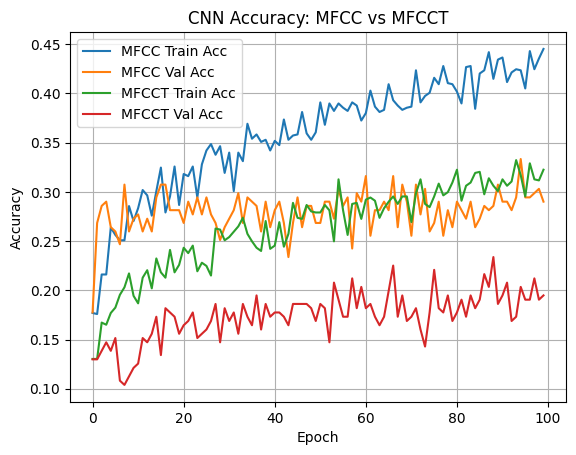

In [19]:
acc_mfcc = model_mfcc.evaluate(X_mfcc_test, y_test, verbose=0)[1]
acc_mfcct = model_mfcct.evaluate(X_mfcct_test, y_test, verbose=0)[1]

print(f"\n🎯 MFCC Accuracy: {acc_mfcc * 100:.2f}%")
print(f"🎯 MFCCT Accuracy: {acc_mfcct * 100:.2f}%")

# ========== STEP 6: Accuracy Plot ==========
plt.plot(history_mfcc.history['accuracy'], label='MFCC Train Acc')
plt.plot(history_mfcc.history['val_accuracy'], label='MFCC Val Acc')
plt.plot(history_mfcct.history['accuracy'], label='MFCCT Train Acc')
plt.plot(history_mfcct.history['val_accuracy'], label='MFCCT Val Acc')
plt.title("CNN Accuracy: MFCC vs MFCCT")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()